Nombre:

Carnet:

# Requirements:

## CNNs
*   Implement the whole ML Pipeline
*   You will be working with the **Fashion MNIST dataset** (hint: the Fashion MNIST dataset can be retrieved in the same manner as the MNIST dataset seen in the demo for CNNs. The line of code is this one: **datasets.fashion_mnist**)
*   Write the technical details of the dataset: How many images of training and test are being used, find the classes and find the shape of the data
*   Must pre process the dataset in some way, form or shape
*   Create an AI that can classify the different pieces of clothing found in the Fashion MNIST dataset
*   Accuracy must be above 60%
*   Include confusion Matrix

## Transfer Learning
*   Make another AI model that solves the same problem as described above but it must utilize Transfer Learning. Up to you if you want to freeze all the layers or only a couple. (Hint: You can search for other existing models in [TensorFlow Hub](https://tfhub.dev) under the **Image domain**.)
*   Compare both models you built and annotate some conclusions
*   Write some suggestions on how to improve the model that got the best performance


## Preparations

In [ ]:
# ----- Libraries ----- #

# This is the main Library that allows us to work with Neural Networks
import tensorflow as tf

# For graph plotting
import matplotlib.pyplot as plt
from tensorflow.math import confusion_matrix

# For dataset manipulation
import pandas as pd
from sklearn.model_selection import train_test_split
import numpy as np

# For visualizing more complex graphs
import seaborn as sns

# Global constant for training acceleration
AUTOTUNE = tf.data.AUTOTUNE

# 1) Dataset Preparations

In [ ]:
# Fashion MNIST is a popular dataset ready to be used
from tensorflow.keras import datasets
# Almacenamos el dataset y lo dividimos en train y test junto con sus labels
(train_images, train_labels), (test_images, test_labels) = datasets.fashion_mnist.load_data()

train_images = np.expand_dims(train_images, axis=-1)
train_images = np.repeat(train_images, 3, axis=-1)
train_images = train_images.astype('float32') / 255
train_images = tf.image.resize(train_images, [32,32])
test_images = np.expand_dims(test_images, axis=-1)
test_images = np.repeat(test_images, 3, axis=-1)
test_images = test_images.astype('float32') / 255
test_images = tf.image.resize(test_images, [32,32])



In [ ]:
#Vemos que el shape sea el adecuado
train_images.shape, train_images[0].shape

(TensorShape([60000, 32, 32, 3]), TensorShape([32, 32, 3]))

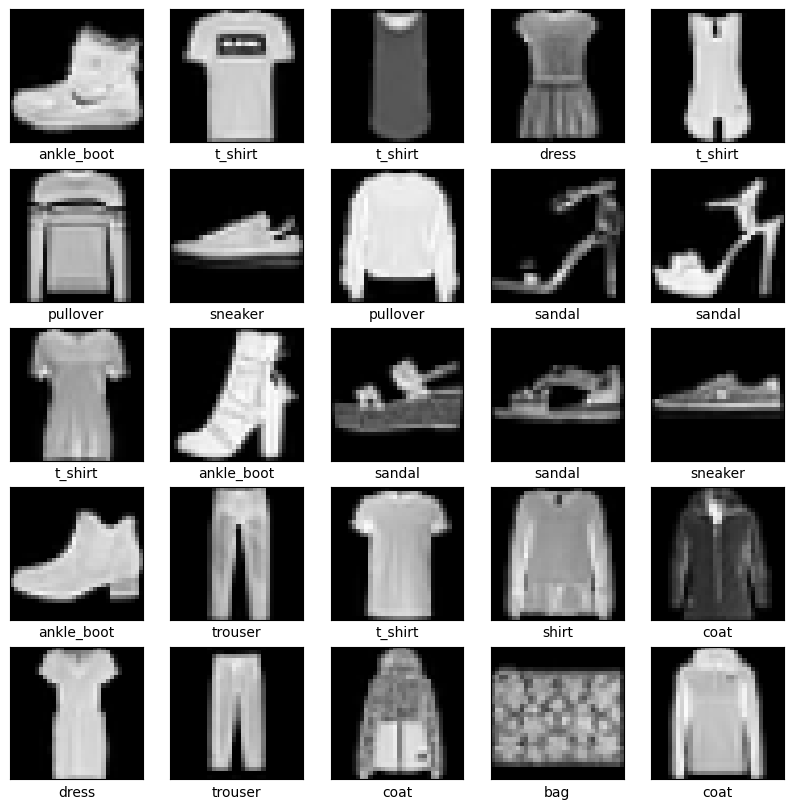

In [ ]:
#colocamos nombres a las variables y monstramos algunas imagenes
class_names = ['t_shirt', 'trouser', 'pullover', 'dress', 'coat', 'sandal', 'shirt', 'sneaker', 'bag', 'ankle_boot']
plt.figure(figsize=(10,10))
for i in range(25):
    plt.subplot(5,5,i+1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(train_images[i])


    plt.xlabel(class_names[train_labels[i]])
plt.show()


In [ ]:
#Declaramos los callbacks a utilizar
checkpoint_callback = tf.keras.callbacks.ModelCheckpoint('logs/model/model.keras', monitor='val_loss', verbose=1, save_best_only=True, mode='auto',save_freq='epoch') # Added 'model.keras' to the filepath to specify filename and format
earlystopping_callback = tf.keras.callbacks.EarlyStopping(monitor='val_loss', min_delta=0.01, patience=3,)


In [ ]:
#El modelo que utilizaremos es MobileNetV2
transfer_model = tf.keras.applications.MobileNetV2(
    input_shape=(32, 32, 3),
    include_top=False,
    weights='imagenet')

transfer_model.trainable = False

print('Number of layers:', len(transfer_model.layers))

<ipython-input-18-c6a7ecbf4c14>:2: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  transfer_model = tf.keras.applications.MobileNetV2(


Number of layers: 154


In [ ]:
model = tf.keras.models.Sequential([
  #Colocamos en los parametros el modelo para hacer transfer Learning
  transfer_model,
  tf.keras.layers.Flatten(),
  tf.keras.layers.Dense(units=128, activation='relu'),
  tf.keras.layers.Dense(units=len(class_names), activation='softmax')
  ])

#Compilamos el modelo y entrenamos
model.compile(loss=tf.keras.losses.SparseCategoricalCrossentropy(), optimizer='adam', metrics=['accuracy'])

model.fit(train_images,
          train_labels,
          epochs=100,
          batch_size = 512,
          validation_split=0.2,
          callbacks=[checkpoint_callback, earlystopping_callback]
        )

Epoch 1/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.3866 - loss: 1.9557
Epoch 1: val_loss improved from inf to 1.25352, saving model to logs/model/model.keras
94/94 ━━━━━━━━━━━━━━━━━━━━ 15s 88ms/step - accuracy: 0.3877 - loss: 1.9527 - val_accuracy: 0.5928 - val_loss: 1.2535
Epoch 2/100
92/94 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.6069 - loss: 1.1784
Epoch 2: val_loss improved from 1.25352 to 1.09881, saving model to logs/model/model.keras
94/94 ━━━━━━━━━━━━━━━━━━━━ 2s 25ms/step - accuracy: 0.6070 - loss: 1.1773 - val_accuracy: 0.6140 - val_loss: 1.0988
Epoch 3/100
93/94 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.6237 - loss: 1.0656
Epoch 3: val_loss improved from 1.09881 to 1.05856, saving model to logs/model/model.keras
94/94 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - accuracy: 0.6237 - loss: 1.0653 - val_accuracy: 0.6229 - val_loss: 1.0586
Epoch 4/100
90/94 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.6355 - loss: 1.0202
Epoch 4: val_loss improved from 1.0585

In [ ]:
#Evaluamos
model.evaluate(x=test_images, y=test_labels, batch_size=128)

79/79 ━━━━━━━━━━━━━━━━━━━━ 4s 30ms/step - accuracy: 0.6715 - loss: 0.9153


[0.9172866344451904, 0.667900025844574]

Luego de implementar ambos enfoques, se observó que el modelo con arquitectura propia basada en redes convolucionales (CNN) logró una mejor precisión al clasificar las diferentes prendas de vestir del dataset.

Por otro lado, el modelo basado en Transfer Learning ofreció una ventaja importante: con menos trabajo y sin diseñar una arquitectura desde cero, fue posible alcanzar una precisión superior a la requerida. Al tratarse de un modelo previamente entrenado y ampliamente optimizado, su tiempo de compilación fue considerablemente menor en comparación con el modelo CNN.

Sin embargo, una desventaja de Transfer Learning es la falta de control y conocimiento sobre los procesos internos del modelo. Si no se adapta bien a nuestra tarea específica, sería necesario buscar otro modelo preentrenado, y debido a que cada uno requiere un tipo de preprocesamiento distinto, esto implicaría rehacer parte del flujo de trabajo. Por lo tanto, cada técnica tiene su contexto ideal de uso: CNN para soluciones personalizadas, Transfer Learning para prototipos rápidos o tareas más generales.

Mejoras a futuro
Para mejorar el desempeño del modelo CNN, se podría trabajar en los errores detectados a través de la matriz de confusión. En particular, el modelo tuvo dificultades para diferenciar entre camisetas (t-shirt) y camisas (shirt). Una posible solución sería aumentar la cantidad de muestras de estas dos clases para reforzar el entrenamiento y permitir que el modelo aprenda mejor sus diferencias.

Además, podrían explorarse mejoras en la arquitectura, como ajustar el número de capas, cambiar la cantidad de neuronas o añadir más capas convolucionales y de pooling. No obstante, debido al tiempo que toma entrenar nuevamente el modelo, estos cambios se considerarían solo si son necesarios para alcanzar una mejora significativa en la precisión.

# READ ME

When you are finished with your laboratory, remember to share it. Make the URL public for Galileo.edu domain or for everyone.
Also, remember to hit Ctrl+S to save your progress.